# Dynamic Field Learning Sweep Analysis

Analyze results from `field_learning_sweep_dynamic.py`:
- Moving Gaussian blobs (time-dependent fields)
- Input: (x, y, z, t) -> gradient or scalar
- MLP (ReLU/Tanh/GELU) vs SIREN
- Batch = frames x spatial points (like GNN training)

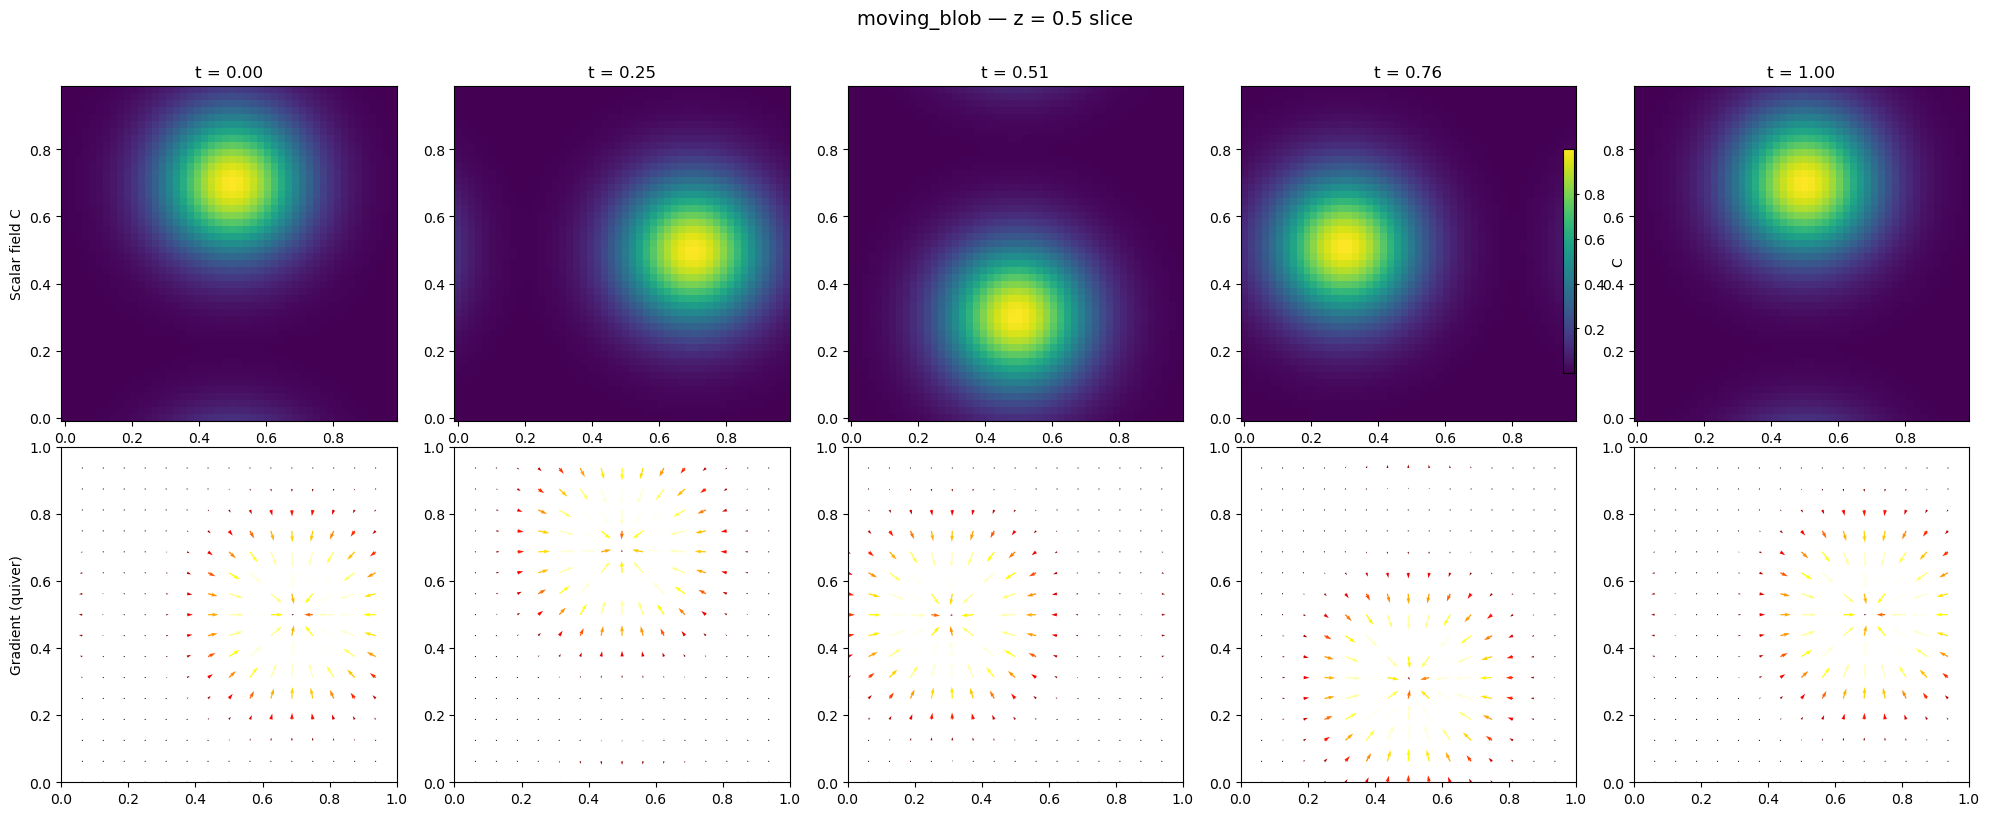

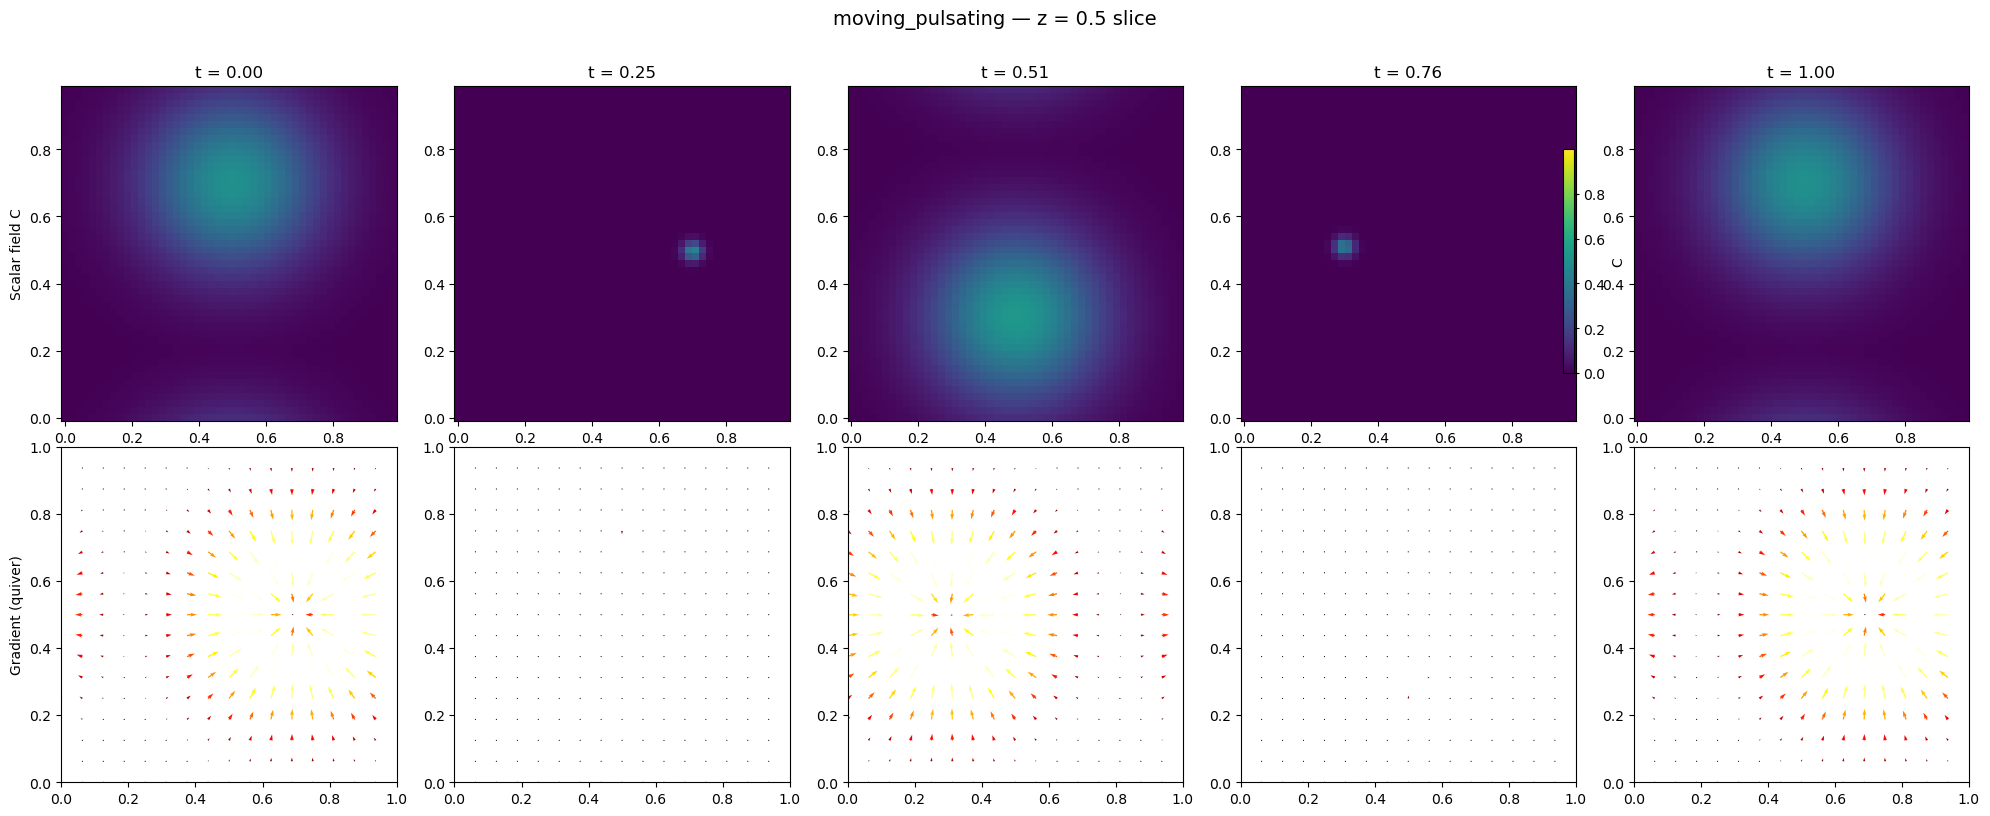

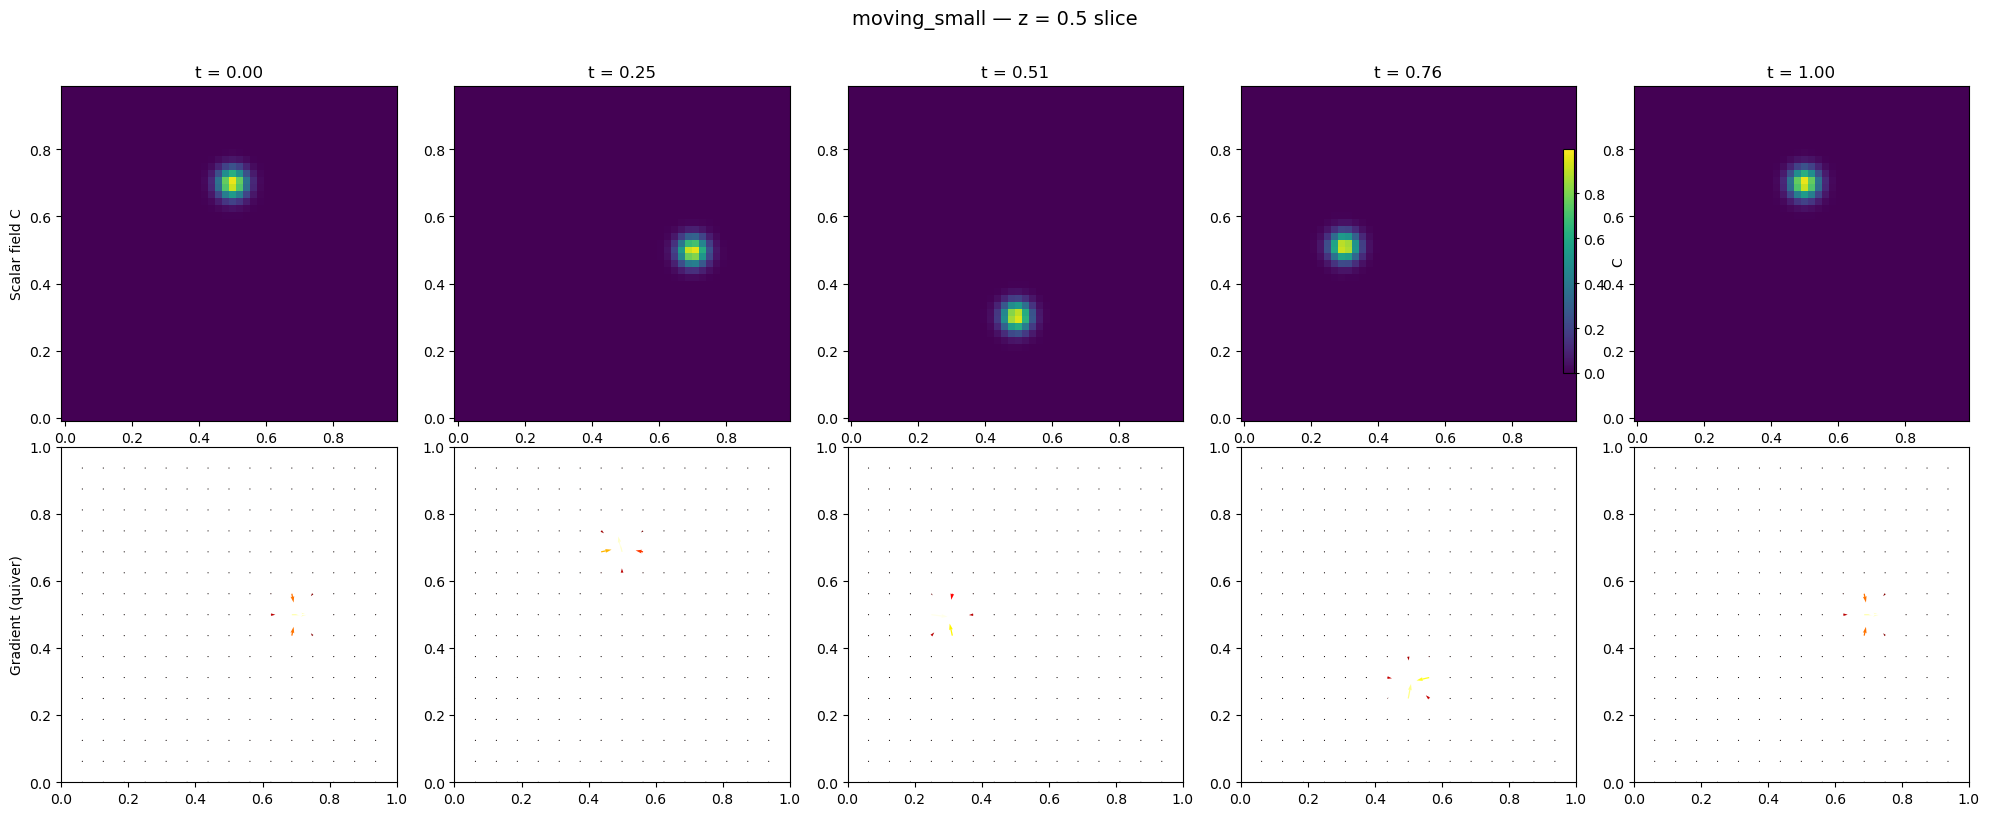

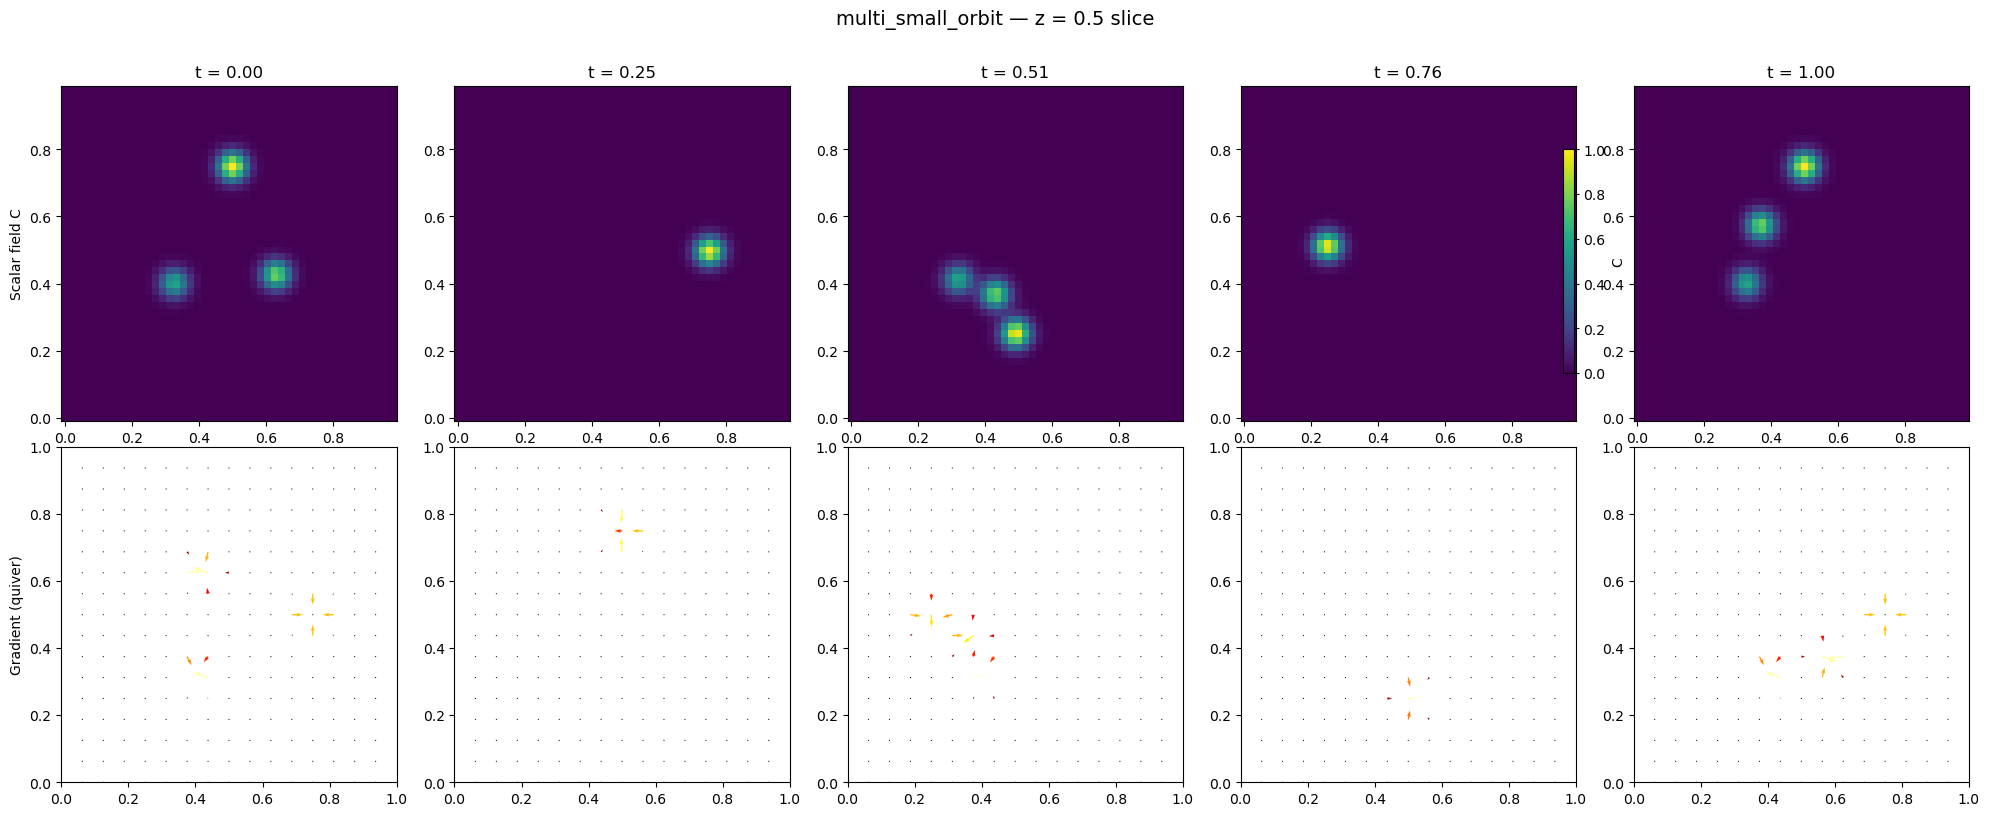

In [1]:
import sys
sys.path.insert(0, '../src')

import torch
import numpy as np
import matplotlib.pyplot as plt
from cell_gnn.experiments.field_learning_sweep_dynamic import DYNAMIC_FIELDS

device = 'cpu'
Nx = 48
L = 1.0
n_frames = 100
z_slice_idx = Nx // 2  # z = 0.5 slice

dx = L / Nx
coords = np.arange(Nx) * dx

# Show all 4 dynamic fields at 5 time snapshots
field_names = ['moving_blob', 'moving_pulsating', 'moving_small', 'multi_small_orbit']
time_indices = [0, 25, 50, 75, 99]

for field_name in field_names:
    field_fn = DYNAMIC_FIELDS[field_name]
    X, Y, Z, times, c_all, gc_all = field_fn(Nx, L, n_frames, device)
    # c_all: (n_frames, Nx, Nx, Nx)
    # gc_all: (n_frames, Nx, Nx, Nx, 3)

    fig, axes = plt.subplots(2, len(time_indices), figsize=(4 * len(time_indices), 8))

    # shared color range for scalar field
    vmin_c = c_all[:, :, :, z_slice_idx].min().item()
    vmax_c = c_all[:, :, :, z_slice_idx].max().item()

    for col, ti in enumerate(time_indices):
        t_val = times[ti].item()

        # Row 1: scalar field C (z-slice)
        c_slice = c_all[ti, :, :, z_slice_idx].numpy()
        im = axes[0, col].pcolormesh(coords, coords, c_slice, cmap='viridis',
                                      vmin=vmin_c, vmax=vmax_c)
        axes[0, col].set_title(f't = {t_val:.2f}')
        axes[0, col].set_aspect('equal')
        if col == 0:
            axes[0, col].set_ylabel('Scalar field C')

        # Row 2: gradient field (quiver, z-slice, subsample for clarity)
        step = max(1, Nx // 16)
        gx_slice = gc_all[ti, ::step, ::step, z_slice_idx, 0].numpy()
        gy_slice = gc_all[ti, ::step, ::step, z_slice_idx, 1].numpy()
        grad_mag = np.sqrt(gx_slice**2 + gy_slice**2)
        xq = coords[::step]
        yq = coords[::step]
        Xq, Yq = np.meshgrid(xq, yq, indexing='ij')
        axes[1, col].quiver(Xq, Yq, gx_slice, gy_slice, grad_mag,
                            cmap='hot', scale=grad_mag.max() * 20 if grad_mag.max() > 0 else 1)
        axes[1, col].set_aspect('equal')
        axes[1, col].set_xlim(0, L)
        axes[1, col].set_ylim(0, L)
        if col == 0:
            axes[1, col].set_ylabel('Gradient (quiver)')

    plt.colorbar(im, ax=axes[0, :].tolist(), shrink=0.8, label='C')
    fig.suptitle(f'{field_name} — z = 0.5 slice', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 0. Visualize the dynamic fields — what do they look like?

In [51]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_path = Path('../results/field_sweep_dynamic_h32/sweep_results_merged.npz')
data = np.load(results_path, allow_pickle=True)
all_results = json.loads(str(data['results']))

results = [r for r in all_results if 'error' not in r]
print(f'Loaded {len(results)} successful experiments out of {len(all_results)} total')

Loaded 400 successful experiments out of 400 total


In [52]:
rows = []
for r in results:
    c = r['config']
    rows.append({
        'field': c['field_name'],
        'target': c['target'],
        'arch': c['arch'],
        'lr': c['lr'],
        'n_layers': c['n_layers'],
        'hidden_size': c['hidden_size'],
        'omega': c.get('omega', None),
        'n_frames': c['n_frames'],
        'batch_frames': c['batch_frames'],
        'batch_points': c['batch_points'],
        'final_rel_error': r['final_rel_error'],
        'final_loss': r['final_loss'],
        'n_params': r['n_params'],
        'time_s': r['time_seconds'],
        'converged': r['converged'],
    })
df = pd.DataFrame(rows)
print(f'Shape: {df.shape}')
print(f"Converged: {df['converged'].sum()} / {len(df)}")
print(f'Fields: {sorted(df["field"].unique())}')
print(f'Archs: {sorted(df["arch"].unique())}')
df.head()

Shape: (400, 15)
Converged: 36 / 400
Fields: ['moving_blob', 'moving_pulsating', 'moving_small', 'multi_small_orbit']
Archs: ['gelu', 'relu', 'siren', 'tanh']


,field,target,arch,lr,n_layers,hidden_size,omega,n_frames,batch_frames,batch_points,final_rel_error,final_loss,n_params,time_s,converged
0,moving_blob,gradient,relu,0.0001,5,32,30.0,100,8,10000,0.743283,0.013314,3427,52.694014,False
1,moving_blob,gradient,relu,0.0005,5,32,30.0,100,8,10000,0.228380,0.001388,3427,52.586885,False
2,moving_blob,gradient,relu,0.0010,5,32,30.0,100,8,10000,0.176128,0.000753,3427,52.597518,False
3,moving_blob,gradient,relu,0.0030,5,32,30.0,100,8,10000,0.144675,0.000487,3427,52.632567,False
4,moving_blob,gradient,tanh,0.0001,5,32,30.0,100,8,10000,0.962697,0.024104,3427,52.590464,False


## 1. Architecture comparison

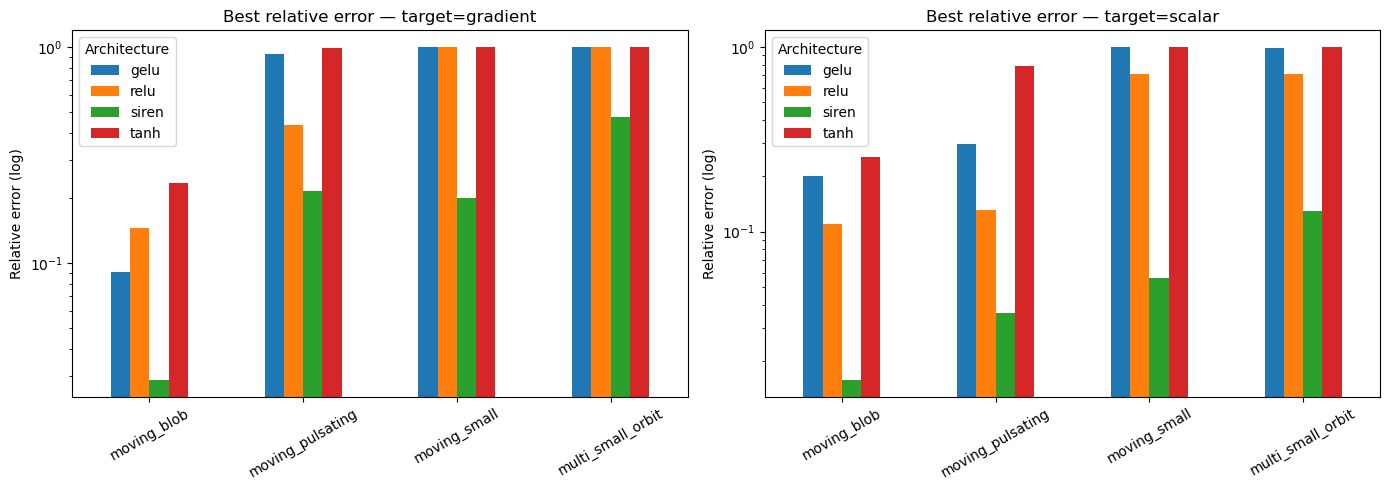

In [60]:
default_mask = (df['n_layers'] == 5) & (df['hidden_size'] == 32)
best = df[default_mask].groupby(['field', 'target', 'arch'])['final_rel_error'].min().unstack('arch')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, target in enumerate(['gradient', 'scalar']):
    sub = best.xs(target, level='target') if target in best.index.get_level_values('target') else None
    if sub is not None:
        sub.plot(kind='bar', ax=axes[i], logy=True)
        axes[i].set_title(f'Best relative error — target={target}')
        axes[i].set_ylabel('Relative error (log)')
        axes[i].set_xlabel('')
        axes[i].legend(title='Architecture')
        axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 2. Learning rate sensitivity

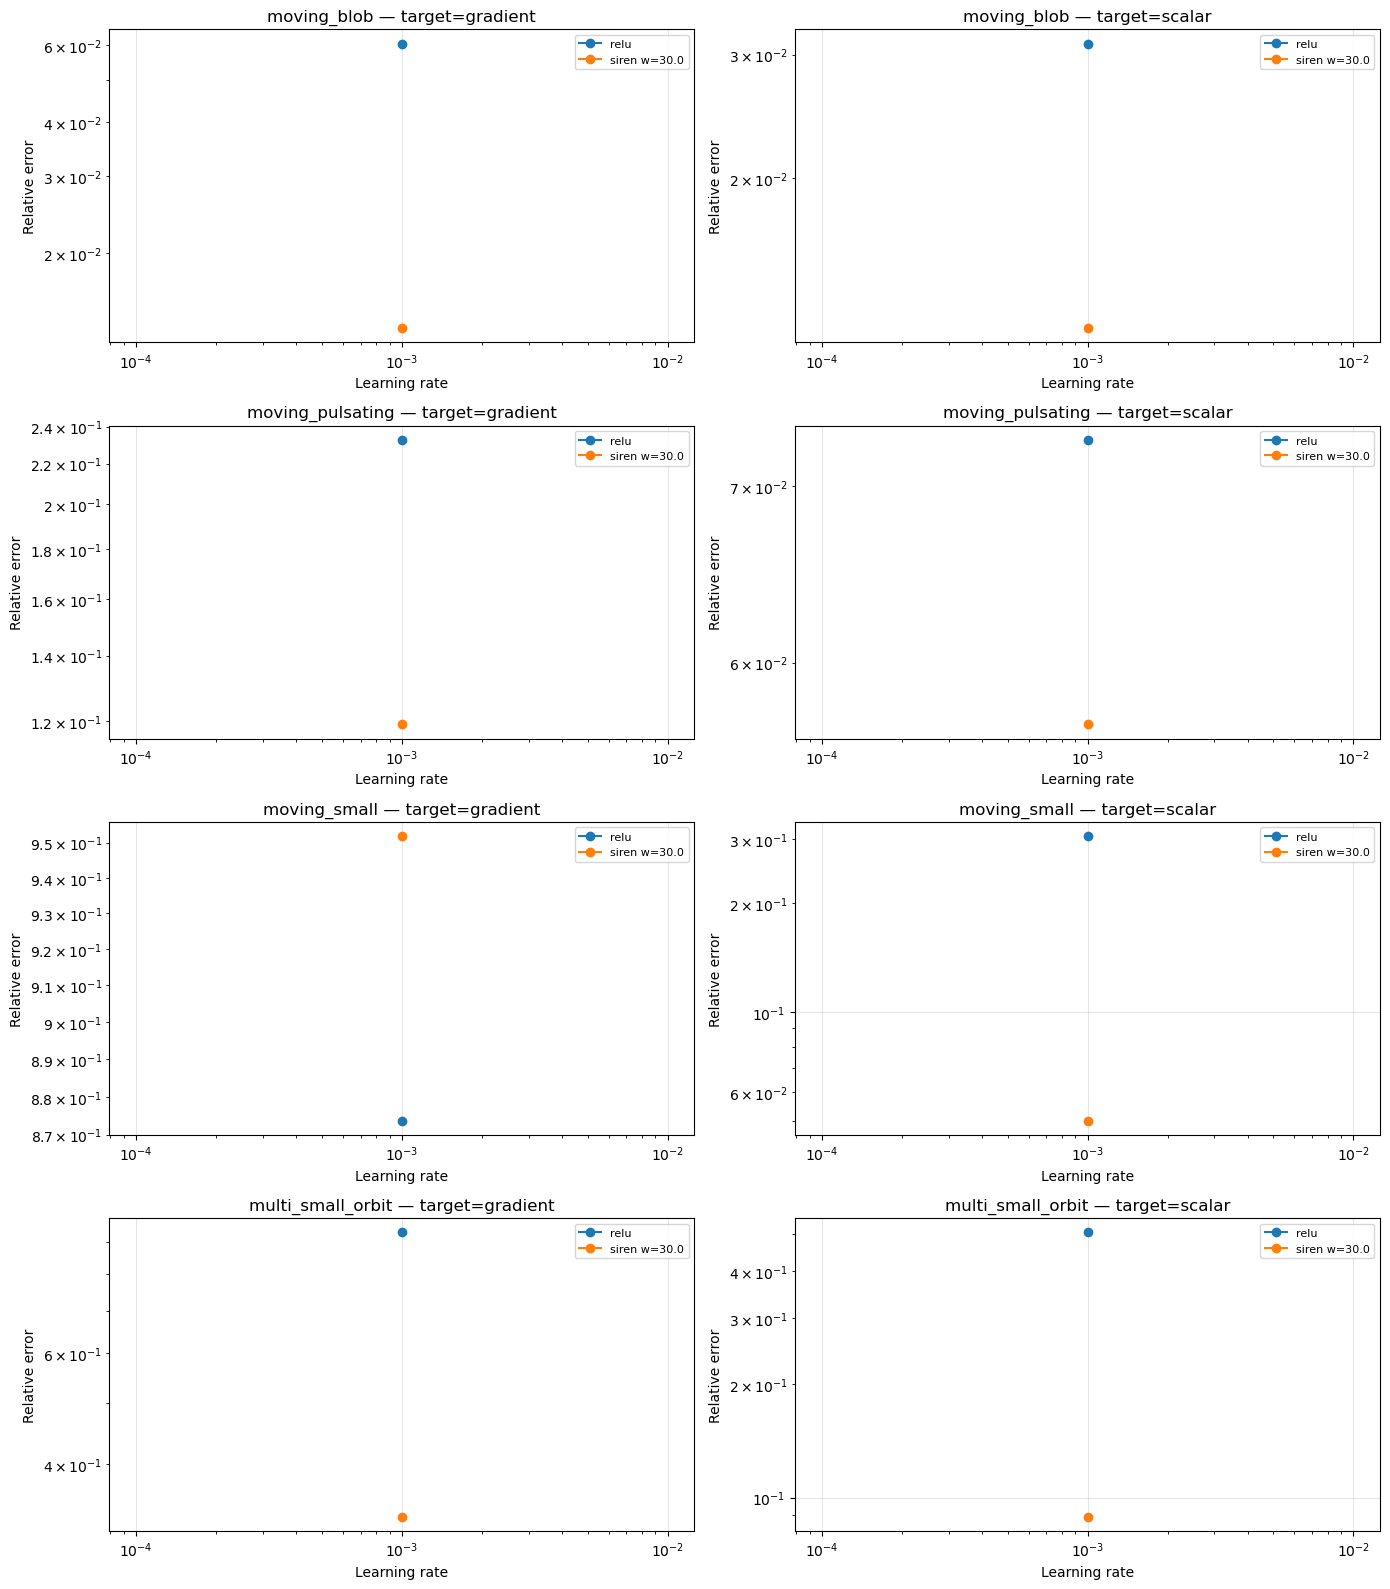

In [54]:
fields = df['field'].unique()
archs = df['arch'].unique()

fig, axes = plt.subplots(len(fields), 2, figsize=(14, 4 * len(fields)), squeeze=False)

for row, field_name in enumerate(fields):
    for col, target in enumerate(['gradient', 'scalar']):
        ax = axes[row, col]
        sub = df[(df['field'] == field_name) & (df['target'] == target) &
                 (df['n_layers'] == 5) & (df['hidden_size'] == 128)]
        if sub.empty:
            ax.set_visible(False)
            continue
        for arch in archs:
            s = sub[sub['arch'] == arch].sort_values('lr')
            if not s.empty:
                if arch == 'siren':
                    for omega, sg in s.groupby('omega'):
                        ax.plot(sg['lr'], sg['final_rel_error'], 'o-', label=f'siren w={omega}')
                else:
                    ax.plot(s['lr'], s['final_rel_error'], 'o-', label=arch)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Learning rate')
        ax.set_ylabel('Relative error')
        ax.set_title(f'{field_name} — target={target}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Depth and width effects

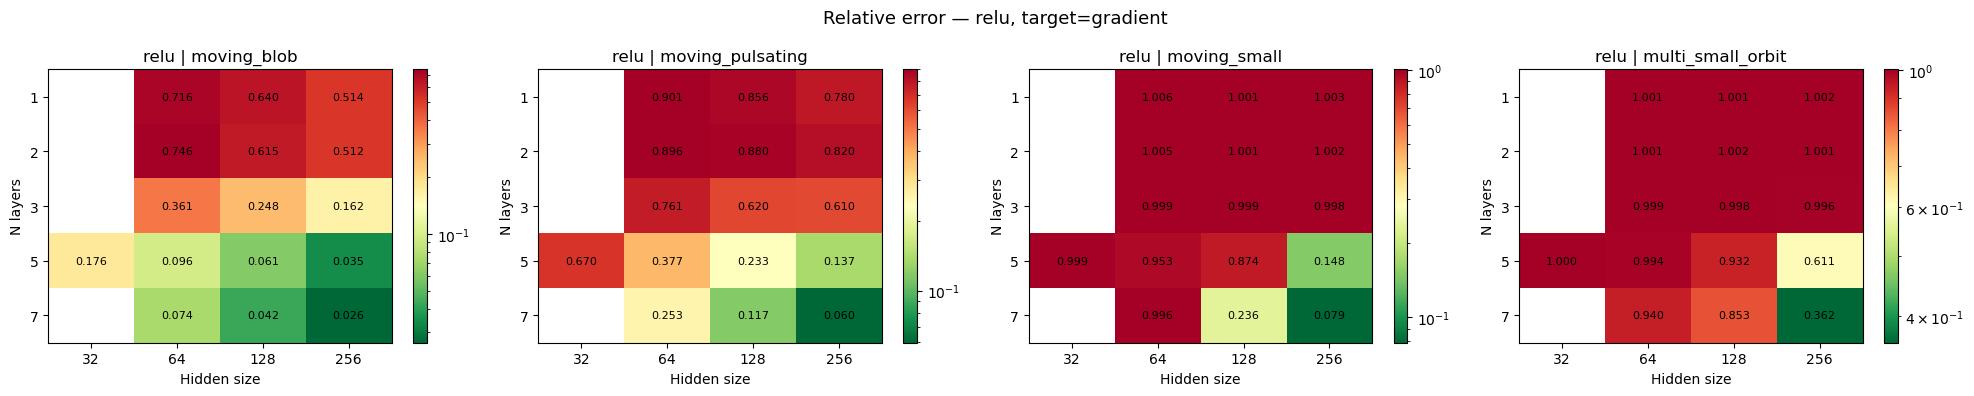

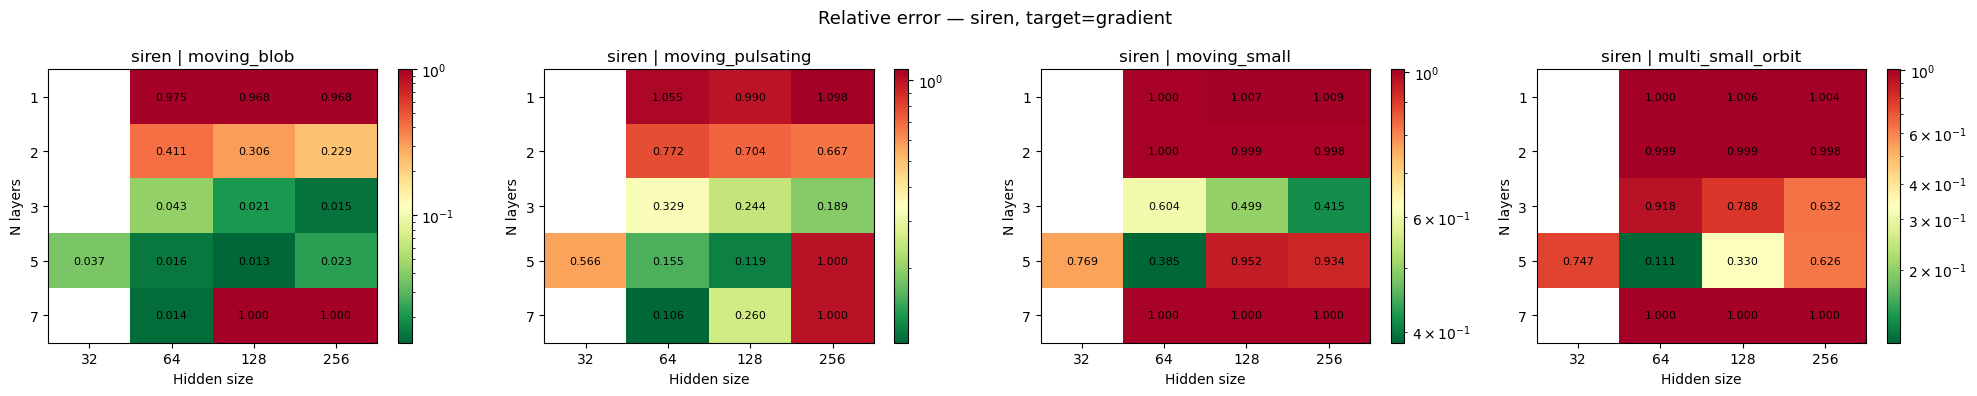

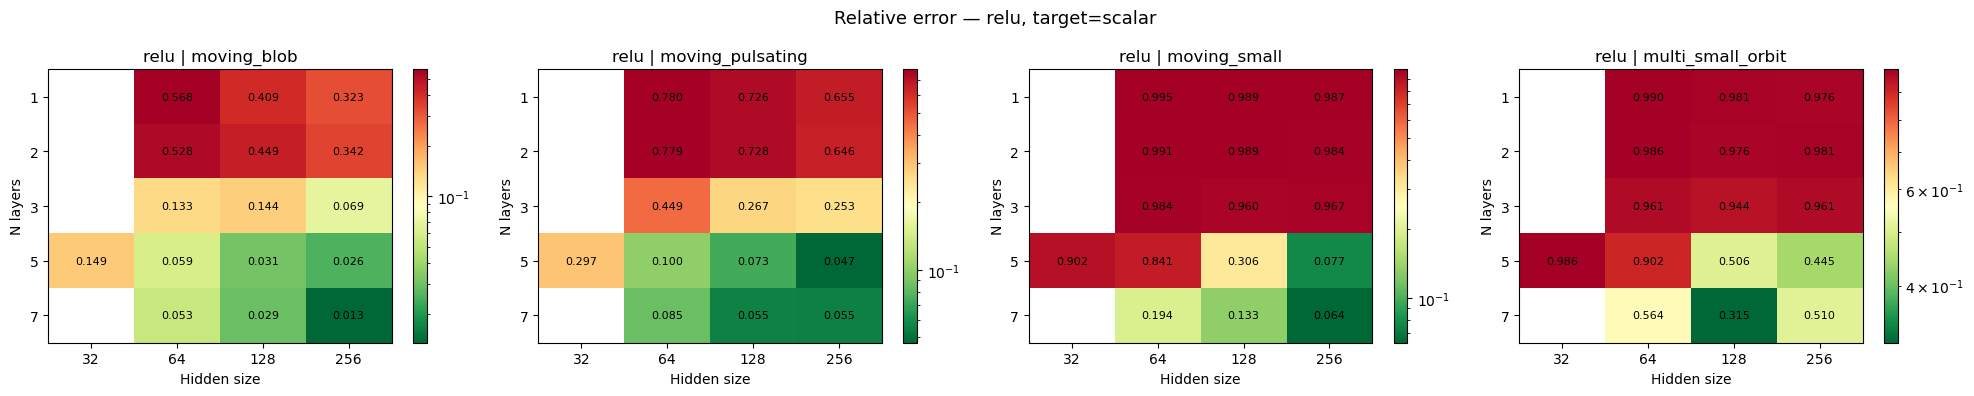

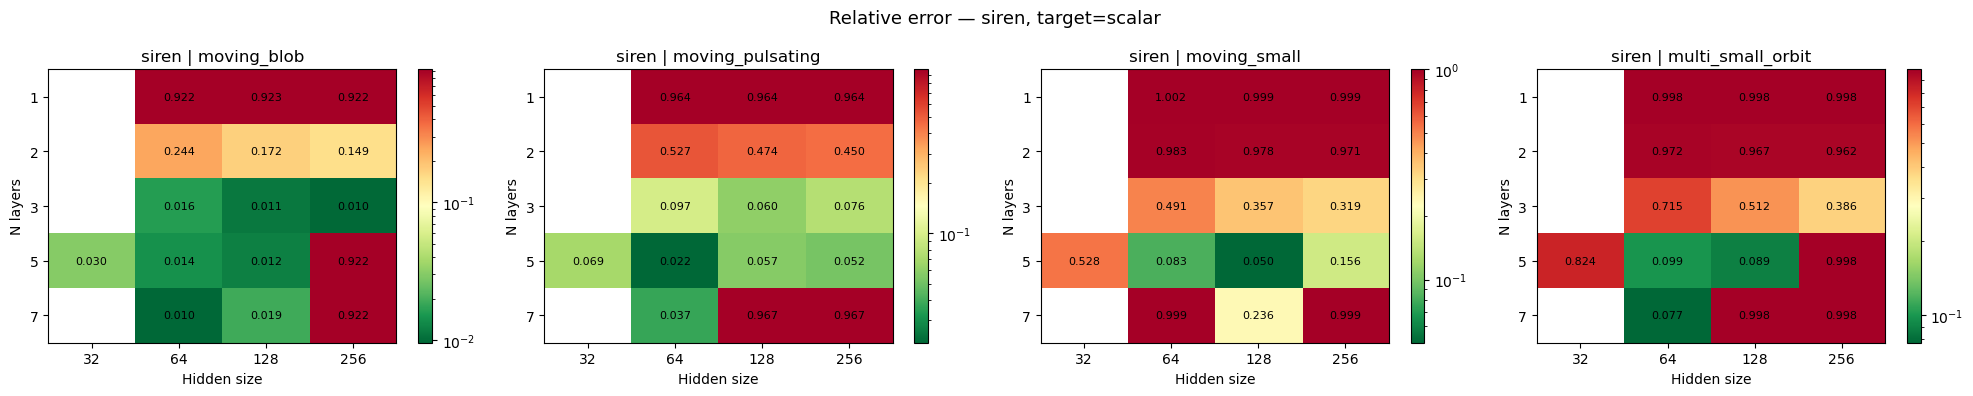

In [55]:
for target in ['gradient', 'scalar']:
    for arch in ['relu', 'siren']:
        sub = df[(df['arch'] == arch) & (df['lr'] == 1e-3) & (df['target'] == target)]
        if sub.empty:
            continue
        fields_here = sub['field'].unique()
        fig, axes = plt.subplots(1, len(fields_here), figsize=(5 * len(fields_here), 4))
        if len(fields_here) == 1:
            axes = [axes]
        for ax, fn in zip(axes, fields_here):
            pivot = sub[sub['field'] == fn].pivot_table(
                values='final_rel_error', index='n_layers', columns='hidden_size')
            im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                           norm=plt.matplotlib.colors.LogNorm())
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_xlabel('Hidden size')
            ax.set_ylabel('N layers')
            ax.set_title(f'{arch} | {fn}')
            for yi in range(len(pivot.index)):
                for xi in range(len(pivot.columns)):
                    val = pivot.values[yi, xi]
                    if not np.isnan(val):
                        ax.text(xi, yi, f'{val:.3f}', ha='center', va='center', fontsize=8)
            plt.colorbar(im, ax=ax)
        fig.suptitle(f'Relative error — {arch}, target={target}', fontsize=13)
        plt.tight_layout()
        plt.show()

## 4. Static vs Dynamic comparison
Load both sweep results to compare how adding time makes the problem harder.

In [56]:
# Load static results if available
static_path = Path('../results/field_sweep/sweep_results.npz')
if static_path.exists():
    static_data = np.load(static_path, allow_pickle=True)
    static_results = json.loads(str(static_data['results']))
    static_results = [r for r in static_results if 'error' not in r]

    # Best per arch for single_gaussian (static) vs moving_blob (dynamic)
    static_best = {}
    for r in static_results:
        c = r['config']
        if c['field_name'] == 'single_gaussian':
            key = (c['arch'], c['target'])
            if key not in static_best or r['final_rel_error'] < static_best[key]:
                static_best[key] = r['final_rel_error']

    dynamic_best = {}
    for r in results:
        c = r['config']
        if c['field_name'] == 'moving_blob':
            key = (c['arch'], c['target'])
            if key not in dynamic_best or r['final_rel_error'] < dynamic_best[key]:
                dynamic_best[key] = r['final_rel_error']

    print(f'{"Arch":<10} {"Target":<10} {"Static":>10} {"Dynamic":>10} {"Ratio":>8}')
    print('-' * 50)
    for key in sorted(set(static_best.keys()) & set(dynamic_best.keys())):
        s, d = static_best[key], dynamic_best[key]
        ratio = d / s if s > 0 else float('inf')
        print(f'{key[0]:<10} {key[1]:<10} {s:>10.4f} {d:>10.4f} {ratio:>8.1f}x')
else:
    print('No static sweep results found — run field_learning_sweep.py first')

Arch       Target         Static    Dynamic    Ratio
--------------------------------------------------
gelu       gradient       0.0366     0.0905      2.5x
gelu       scalar         0.0039     0.1992     51.5x
relu       gradient       0.0183     0.0264      1.4x
relu       scalar         0.0048     0.0134      2.8x
siren      gradient       0.0076     0.0134      1.8x
siren      scalar         0.0010     0.0095      9.3x
tanh       gradient       0.0401     0.2344      5.8x
tanh       scalar         0.0100     0.2544     25.5x


## 5. Convergence curves

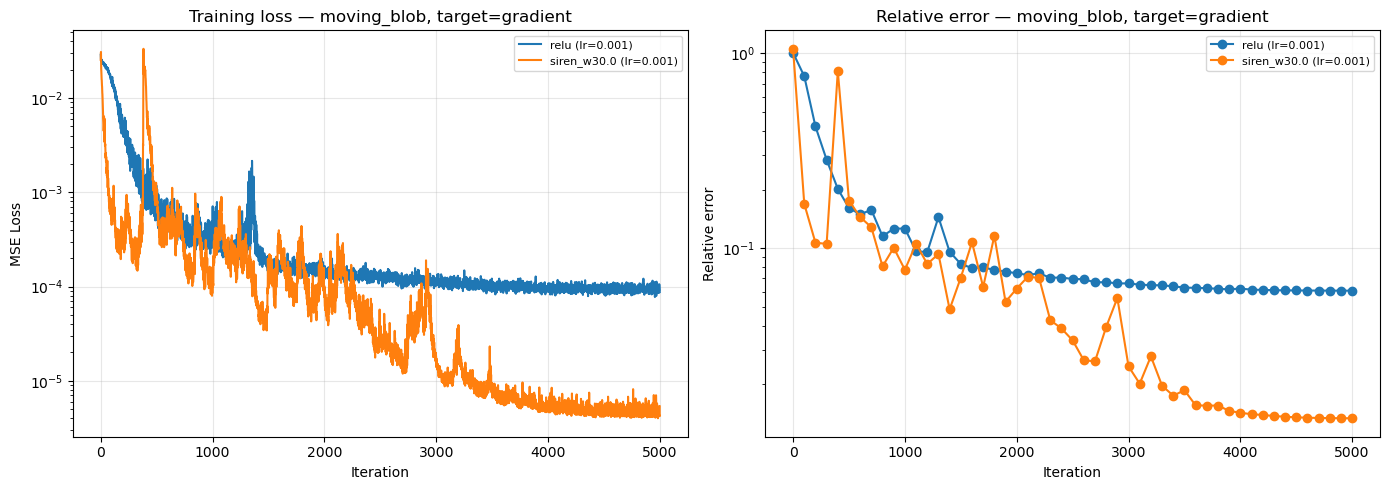

In [57]:
field_name = 'moving_blob'  # change to explore others
target = 'gradient'

sub_results = [r for r in results
               if r['config']['field_name'] == field_name
               and r['config']['target'] == target
               and r['config']['n_layers'] == 5
               and r['config']['hidden_size'] == 128]

best_per_arch = {}
for r in sub_results:
    arch = r['config']['arch']
    key = arch if arch != 'siren' else f"siren_w{r['config']['omega']}"
    if key not in best_per_arch or r['final_rel_error'] < best_per_arch[key]['final_rel_error']:
        best_per_arch[key] = r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in best_per_arch.items():
    lr = r['config']['lr']
    axes[0].semilogy(r['losses'], label=f"{name} (lr={lr})")
    iters, rels = zip(*r['rel_errors'])
    axes[1].semilogy(iters, rels, 'o-', label=f"{name} (lr={lr})")

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title(f'Training loss — {field_name}, target={target}')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Relative error')
axes[1].set_title(f'Relative error — {field_name}, target={target}')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary table

In [58]:
summary = df.loc[df.groupby(['field', 'target', 'arch'])['final_rel_error'].idxmin()]
summary = summary[['field', 'target', 'arch', 'lr', 'n_layers', 'hidden_size',
                    'final_rel_error', 'n_params', 'time_s', 'converged']]
summary = summary.sort_values(['field', 'target', 'final_rel_error'])
summary.reset_index(drop=True, inplace=True)

print(f"Converged: {summary['converged'].sum()} / {len(summary)}")
summary

Converged: 6 / 32


,field,target,arch,lr,n_layers,hidden_size,final_rel_error,n_params,time_s,converged
0,moving_blob,gradient,siren,0.0010,5,128,0.013418,50563,130.268375,True
1,moving_blob,gradient,relu,0.0010,7,256,0.026414,331011,335.845844,True
2,moving_blob,gradient,gelu,0.0030,5,32,0.090490,3427,52.868993,False
3,moving_blob,gradient,tanh,0.0030,5,32,0.234402,3427,52.592682,False
4,moving_blob,scalar,siren,0.0010,7,64,0.009549,21185,150.595468,True
5,moving_blob,scalar,relu,0.0010,7,256,0.013422,330497,358.808402,True
6,moving_blob,scalar,gelu,0.0030,5,32,0.199245,3361,49.934978,False
7,moving_blob,scalar,tanh,0.0030,5,32,0.254444,3361,49.937932,False
8,moving_pulsating,gradient,relu,0.0010,7,256,0.059602,331011,335.033365,False
9,moving_pulsating,gradient,siren,0.0010,7,64,0.105606,21315,154.805095,False


## 7. Failure analysis

In [59]:
print("Failure rate by architecture:")
print(df.groupby('arch')['converged'].apply(lambda x: f"{(~x).sum()}/{len(x)}"))
print()
print("Failure rate by field:")
print(df.groupby('field')['converged'].apply(lambda x: f"{(~x).sum()}/{len(x)}"))
print()
print("Failure rate by target:")
print(df.groupby('target')['converged'].apply(lambda x: f"{(~x).sum()}/{len(x)}"))

Failure rate by architecture:
arch
gelu       32/32
relu     144/152
siren    156/184
tanh       32/32
Name: converged, dtype: object

Failure rate by field:
field
moving_blob           69/100
moving_pulsating      95/100
moving_small         100/100
multi_small_orbit    100/100
Name: converged, dtype: object

Failure rate by target:
target
gradient    186/200
scalar      178/200
Name: converged, dtype: object
